# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_renda = pd.read_csv('Profissão Cientista de Dados M10 A1.csv')
df_renda.head()

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


In [5]:
df_renda = df_renda.select_dtypes(include=['int64', 'float64'])
print(df_renda.columns)


Index(['Unnamed: 0', 'index', 'qtd_filhos', 'idade', 'tempo_emprego',
       'qt_pessoas_residencia', 'renda'],
      dtype='object')


In [7]:
colunas_para_remover = ['index', 'Unnamed: 0']
for col in colunas_para_remover:
    if col in df_renda.columns:
        df_renda = df_renda.drop(columns=[col])

In [8]:
df_renda.corr()

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
qtd_filhos,1.000000,-0.364303,-0.074250,0.896488,0.009567
idade,-0.364303,1.000000,0.323934,-0.338805,0.042570
tempo_emprego,-0.074250,0.323934,1.000000,-0.065748,0.394235
qt_pessoas_residencia,0.896488,-0.338805,-0.065748,1.000000,0.020977
renda,0.009567,0.042570,0.394235,0.020977,1.000000


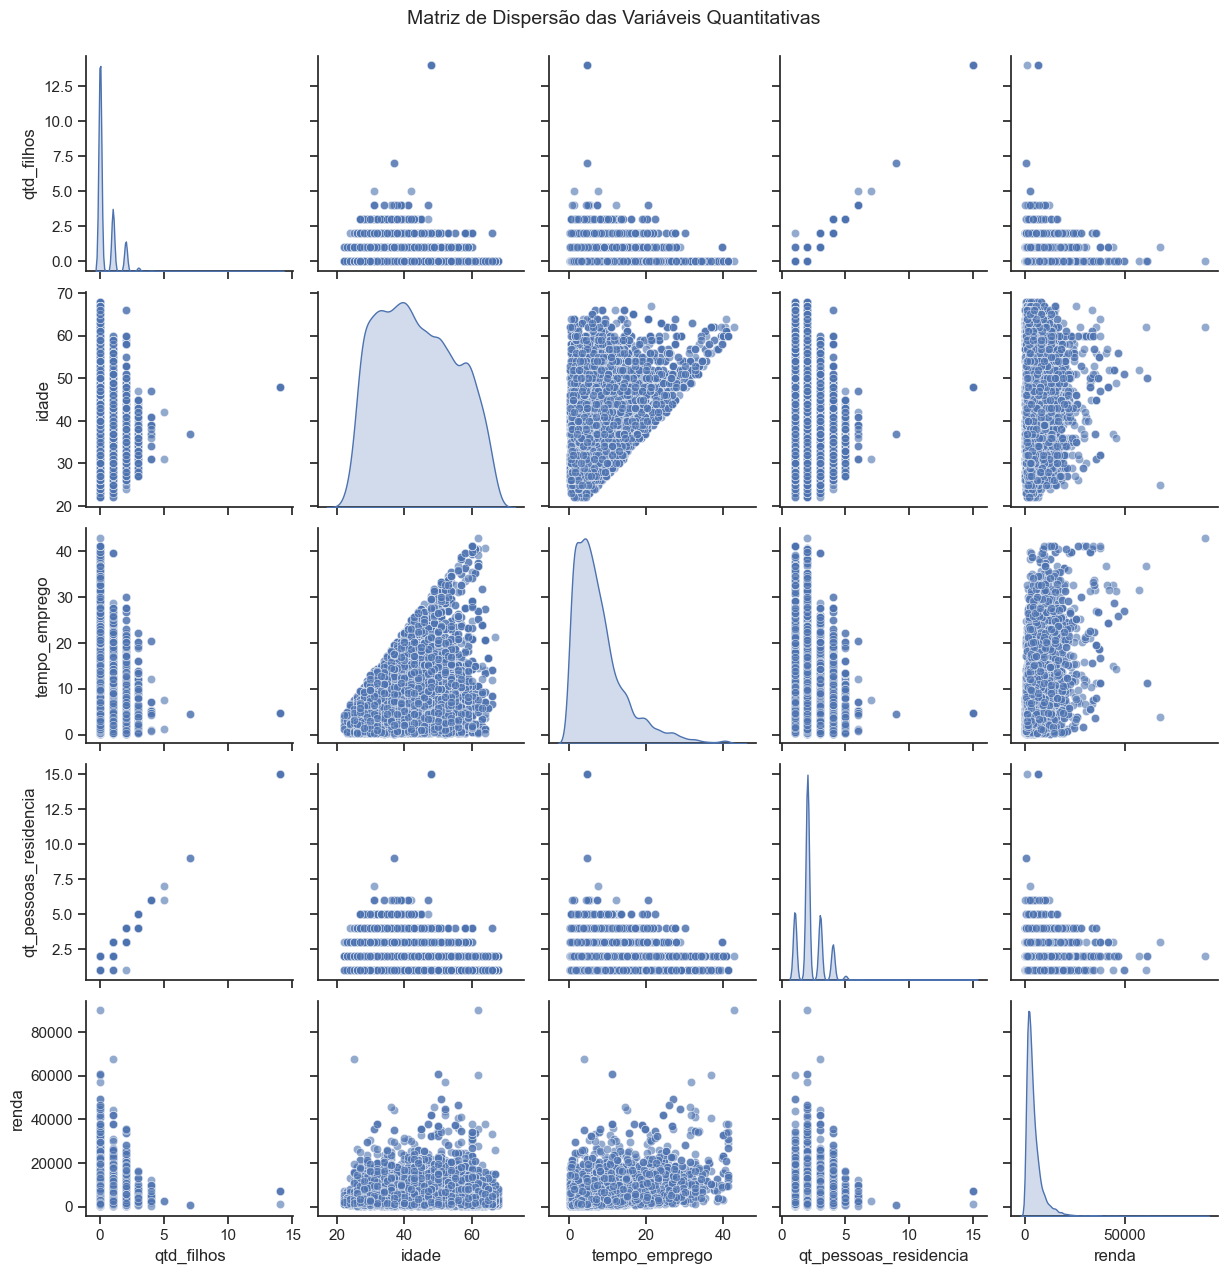

In [9]:
sns.set_theme(style="ticks")

g = sns.pairplot(df_renda, diag_kind='kde', plot_kws={'alpha': 0.6})

g.fig.suptitle("Matriz de Dispersão das Variáveis Quantitativas", y=1.02, fontsize=14)

plt.savefig('matriz_dispersao_clientes.png', bbox_inches='tight', dpi=300)
plt.show()

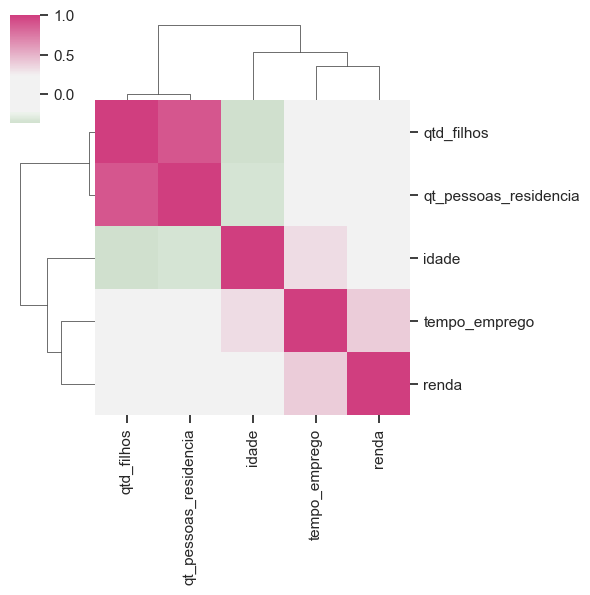

In [10]:
cmap = sns.diverging_palette(h_neg=125, h_pos=350, as_cmap=True, sep = 60, center = 'light')

sns.clustermap(df_renda.corr(), figsize=(6, 6), center = 0, cmap=cmap)

Notei que o tempo de emprego é o grande protagonista: ele possui a correlação mais forte com a renda, mostrando que a estabilidade profissional é um dos melhores indicadores de poder aquisitivo. Também percebi que a renda original é extremamente "poluída" por outliers (aqueles pontos muito altos no gráfico), o que acabava achatando a visão da maioria dos clientes e dificultando qualquer previsão justa.

Quando vi o gráfico após a aplicação do LOG, a mudança foi nítida. A relação, que antes era uma curva "esmagada", tornou-se muito mais linear e organizada. Para mim, ficou evidente que o uso do logaritmo melhorou a análise, pois ele suavizou os valores extremos e permitiu enxergar a tendência real dos dados, o que é essencial para definir limites de cartão de crédito de forma automática e precisa.

 2.Avalie um gráfico de dispersão (scatterplot) específico para as duas variáveis mais correlacionadas com renda.

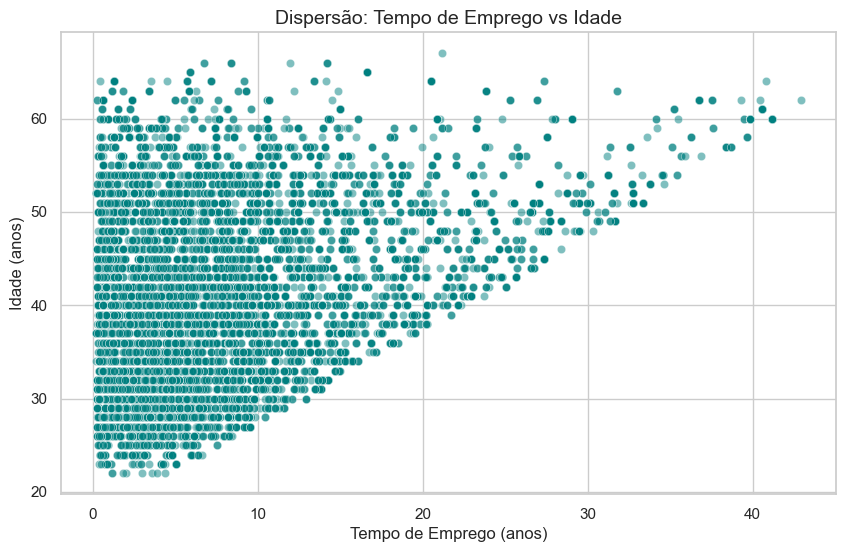

In [11]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(x='tempo_emprego', y='idade', data=df_renda, alpha=0.5, color='teal')

plt.title('Dispersão: Tempo de Emprego vs Idade', fontsize=14)
plt.xlabel('Tempo de Emprego (anos)')
plt.ylabel('Idade (anos)')

plt.show()

3) Na sua opinião, há outliers na variável renda?

Identifiquei que existem outliers na variável renda. Ao observar os gráficos, percebi que a grande maioria dos clientes ganha valores dentro de uma faixa comum, mas há pontos isolados que "disparam" lá no topo, ficando muito distantes do restante do grupo. Esses valores extremos acabam achatando a visão da massa de dados e deslocando a média para cima.

4) Calcule o logaritmo da variável renda e repita a sequência de análise

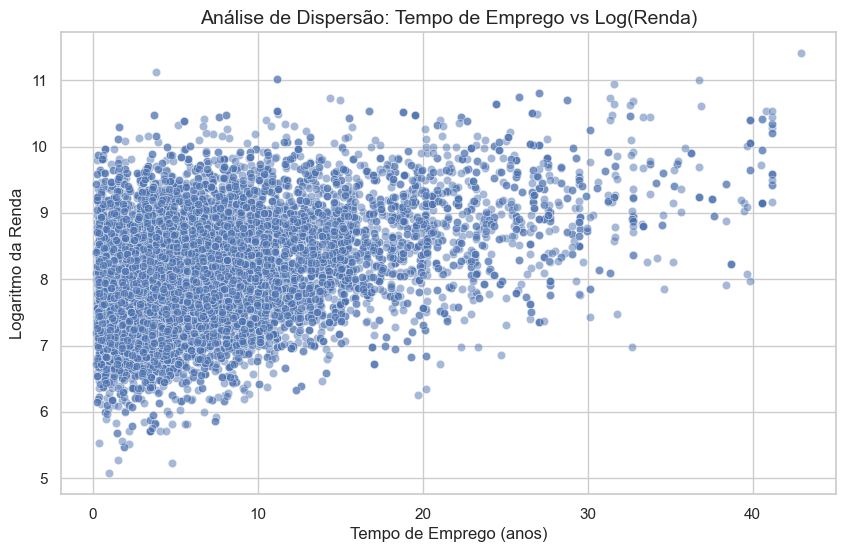

Nova correlação (Tempo de Emprego vs Log_Renda): 0.3796


In [13]:
df_renda['log_renda'] = np.log(df_renda['renda'])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='tempo_emprego', y='log_renda', data=df_renda, alpha=0.5)

plt.title('Análise de Dispersão: Tempo de Emprego vs Log(Renda)', fontsize=14)
plt.xlabel('Tempo de Emprego (anos)')
plt.ylabel('Logaritmo da Renda')

plt.show()

print(f"Nova correlação (Tempo de Emprego vs Log_Renda): {df_renda['tempo_emprego'].corr(df_renda['log_renda']):.4f}")

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

A aplicação do LOG melhorou muito a análise. Percebi que ela "trouxe os dados para a realidade", eliminando aquele achatamento causado pelos outliers e transformando uma nuvem de pontos confusa em uma relação linear muito mais clara.